# QF 627 Programming and Computational Finance
## Problem Set `4` | `Questions`

> "Hi Team! 👋

> The current notebook contains 8 questions that help you review our course content.

> Each question asks you to answer with specific results. Some questions are the `reverse-engineering-type` questions as I have asked in exercise problem set 3. Other questions require direct answers (because, given the nature of the question, reverse-engineering is not feasible).

> These questions won’t be difficult to solve—and working through them will strengthen your understanding of the learning materials. This week’s questions ask you to preview the lecture note script for Lesson 4, which we will continue in Lesson 5, and then attempt to answer the exercises.

> This preview exercise will help you consolidate the upcoming lessons more effectively. Once you have completed it, please submit your script via eLearn.

> Enjoy!"

##### First, let's do some quick exercise with stock prices data.

### <font color = green> Activation of necessary libraries. </font>

In [41]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [42]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

### <font color = red> Question 1</font>. Please import historical stock data from the web on the following financial instruments, and create the following DataFrame that contains adjusted closing prices. 

### Here, the timeframe should be set between the 13th of October 2014 through the 13th of September 2022 (nine years of data).

- `WMT` Stock of Walmart
- `IBM` Stock of IBM

In [43]:
tickers = ['WMT','IBM']
stock_data =\
(
    yf.download(
        tickers,
        start = '2014-10-13',
        end = '2022-09-14',
        auto_adjust=False
    )
)['Adj Close']
                

[*********************100%***********************]  2 of 2 completed


In [44]:
stock_data

Ticker,IBM,WMT
Date,,
2014-10-13,110.969673,20.890917
2014-10-14,111.138992,21.004049
2014-10-15,109.899399,20.255247
2014-10-16,108.744461,19.883535
2014-10-17,110.080833,19.958954
...,...,...
2022-09-07,113.740051,43.546249
2022-09-08,114.416931,43.767612
2022-09-09,115.058167,43.899143


### <font color = red> Question 2</font>. Please run a simple moving average crossover strategy for `IBM`.

### The two moving windows are 20 and 60 days.

### Please show your positions with a plot.

### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

In [45]:
ibm = stock_data[['IBM']]

In [46]:
# get sma
def get_sma(df, sma_list):
    """
    Take DF and given list of SMA to enrich df when stock price is in first column
    """
    for window in sma_list:
        df[f"sma_{window}"] =\
        (
            df[df.columns[0]]
            .rolling(window = window,
                     min_periods = int(window * .8))
            .mean()
        )

    return df

sma_list = [20, 60]
ibm = get_sma(ibm.copy(), sma_list)



In [47]:
ibm['positions'] = \
(
    np.where(ibm['sma_20'] > ibm['sma_60'], 1, -1)
)
ibm['trade'] = ibm['positions'].diff()
ibm = ibm.dropna()

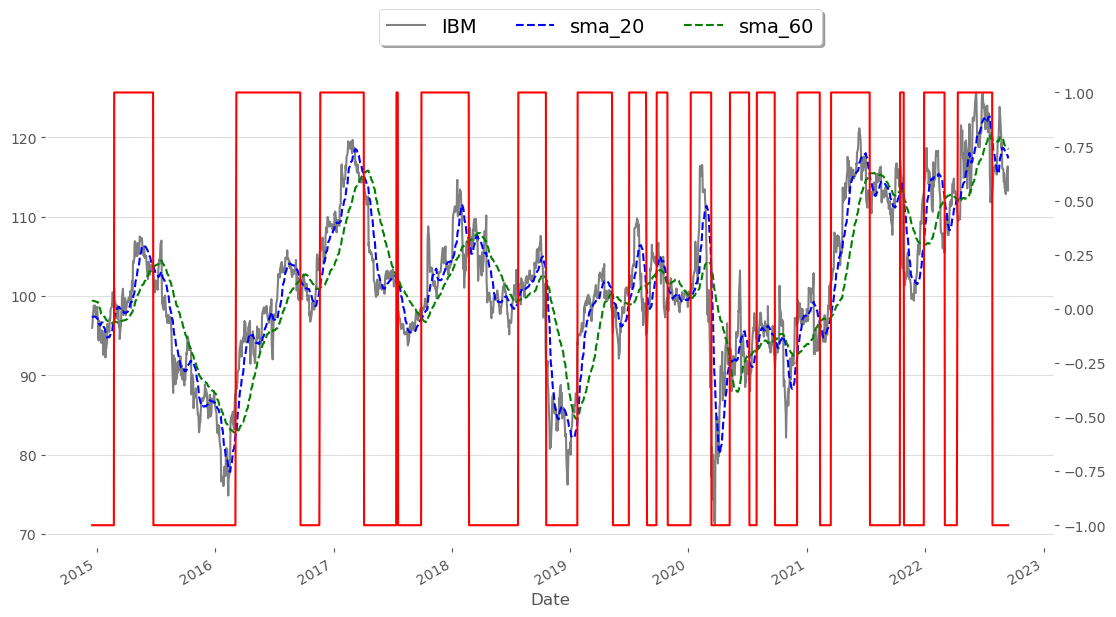

In [48]:
ax = \
ibm.drop(columns=['trade']).plot(
    secondary_y=['positions'],
          style = ["grey", "b--", "g--", "r"],
          figsize = [13, 7]
)

# ax =\
# (
#     ibm
#     [["IBM", "sma_20", "sma_60", "positions"]]
#     .plot(secondary_y = "trading_position",
#           style = ["grey", "b--", "g--", "r"],
#           figsize = [13, 7]
#          )
# )

ax.xaxis.grid(False)

(
    ax
    .legend(loc = "upper center",
            bbox_to_anchor = (0.55, 1.15),
            ncol = 4,
            shadow = True
           )
)

### <font color = red> Question 3</font>. Based on your lines of codes that lead to answer 2 above, compare the returns to see if the strategy leads to a win over the passive benchmark investment.

In [49]:
# get passive return
# get strat return 
# get cum passive return
# get cum strategy return


In [51]:
ibm['IBM'].pct_change()

Date
2014-12-18         NaN
2014-12-19    0.005264
2014-12-22    0.018484
2014-12-23    0.004956
2014-12-24   -0.002589
                ...   
2022-09-07    0.007812
2022-09-08    0.005951
2022-09-09    0.005604
2022-09-12    0.011379
2022-09-13   -0.026098
Name: IBM, Length: 1947, dtype: float64

In [54]:
ibm['passive_returns'] =\
    np.log(
        ibm['IBM'] / ibm['IBM'].shift(1)
    ).fillna(0)

ibm['strategy_returns'] =\
    ibm['passive_returns'] * ibm['positions']

ibm['cum_passive_returns'] =\
    ibm['passive_returns'].cumsum().apply(np.exp)

ibm['cum_strategy_returns'] =\
    ibm['strategy_returns'].cumsum().apply(np.exp)

<AxesSubplot:xlabel='Date'>

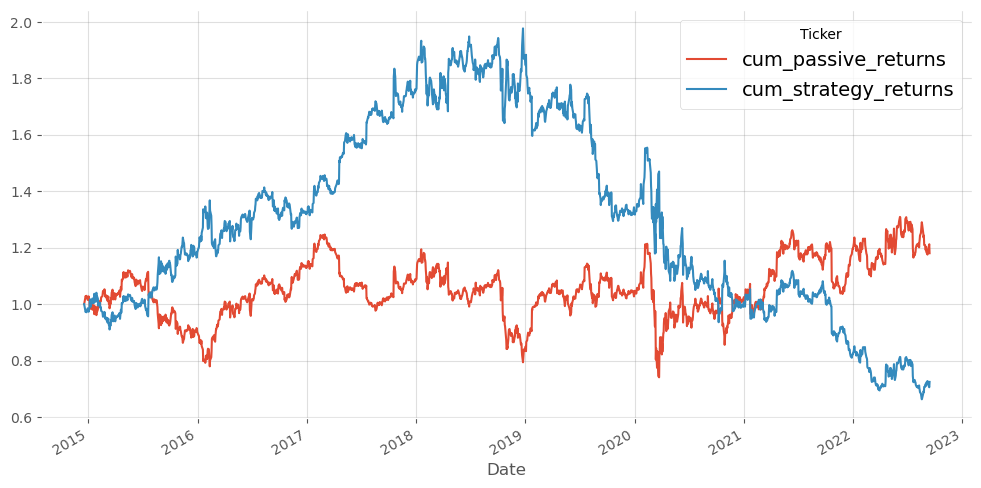

In [57]:
ibm[ibm.columns[-2:]].plot(figsize=[12,6])

### <font color = red> Question 4</font>. Based on your lines of codes that lead to answer 3 above, please calculate the maximum drawdown and the longest drawdown period.

In [59]:
def get_drawdowns(cum_returns):
    """
    Calculate the Maximum Drawdown (MDD) and the Longest Drawdown Duration (LDD)
    from a cumulative returns SERIES.

    Parameters:
      cum_returns : pd.SERIES of cumulative returns
    Returns:
      tuple (mdd, ldd)
    Usage: 
      get_drawdowns(df['cum_strategy_returns'])
    """
    def compute_longest_drawdown_period(dd, cum_returns):
      periods =\
      (
          np
          .diff(np.append(dd[dd == 0].index,
                          dd.index[-1: ]
                        )
              )
      )
      return periods.max() / np.timedelta64(1, "D")
    
    daily_drawdown = cum_returns / cum_returns.cummax() - 1
    mdd = daily_drawdown.min()
    ldd = compute_longest_drawdown_period(daily_drawdown, cum_returns) # days
    return mdd, ldd


mdd, ldd = get_drawdowns(ibm['cum_strategy_returns'])



### Please make sure to answer below.

    The maximum drawdown is about ___________ percentage points.
    The longest drawdown period lasts for ___________ days.

In [63]:
f"    The maximum drawdown is about {mdd:.2%} percentage points."\
f"    The longest drawdown period lasts for {ldd:.0f} days."

'    The maximum drawdown is about -66.47% percentage points.    The longest drawdown period lasts for 1359 days.'

### <font color = red> Question 5</font>. Now let’s have a look at the stock price of Walmart (WMT). Please run a simple moving average crossover strategy.

### The two moving windows are 50 and 200 days.

### Now, please visualize your buy positions using red dots, and your sell positions using blue dots.

In [65]:
wmt = stock_data[['WMT']]

In [72]:
def get_momentum_strategy(df, sma_tuple):
    """
    Apply single stock momentum strategy pipeline to price DataFrame `df`. 
    Price is in first column.
    Adds columns:
      positions, trade, passive_returns, strategy_returns,
      cum_returns, cum_strategy_returns
    Parameters:
      df        : pd.DataFrame with price columns for ticker name as the header
      sma_tuple : tuple of (short_window, long_window) for SMAs
    Returns:
      pd.DataFrame with the above columns
    """
    def get_sma(df, sma_list):
        """
        Take DF and given list of SMA to enrich df when stock price is in first column
        """
        for window in sma_list:
            df[f"sma_{window}"] =\
            (
                df[df.columns[0]]
                .rolling(window = window,
                         min_periods = int(window * .8))
                .mean()
            )

        return df
    sma_short, sma_long = sma_tuple
    if sma_short >= sma_long:
        raise ValueError("sma_short must be less than sma_long")
    df = get_sma(df, list(sma_tuple)).dropna()

    df['positions'] =\
    (
        np.where((df[f'sma_{sma_short}'] > df[f'sma_{sma_long}']), 1, -1)
    )
    df['trade'] = \
    (
        df['positions'].diff().fillna(0)
    )
    if df.at[df.index[0], 'positions'] != 0:
        df.at[df.index[0], 'trade'] = df.at[df.index[0], 'positions']
    df['passive_returns'] =\
    (
        np.log(df[df.columns[0]] 
            / df[df.columns[0]].shift(1))
    ).fillna(0)
    df['strategy_returns'] =\
    (
        df['passive_returns'] * df['positions'].shift(1).fillna(0)
    )
    df['cum_returns'] =\
    (
        df['passive_returns'].cumsum().apply(np.exp).fillna(1)
    )
    df['cum_strategy_returns'] =\
    (
        df['strategy_returns'].cumsum().apply(np.exp).fillna(1)
    )

    return df

sma_tup = (50, 200)
wmt = get_momentum_strategy(stock_data[['WMT']], sma_tup)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_43298/3214239951.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['positions'] =\
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_43298/3214239951.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trade'] = \
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_43298/3214239951.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

In [74]:
# TODO get_plot lets-plot; basic 
from lets_plot import *
LetsPlot.setup_html()

wmt_melt = wmt.reset_index()
# wmt_melt = wmt_melt.rename(columns={'index':'Date'}). # optional depending if index is called 'Date'

p =\
(
    ggplot(wmt_melt, aes(x='Date')) +
    geom_line(aes(y='WMT'), color='grey', size=0.7) +
    geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +   # amend sma as required
    geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
    geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']>0.0], color='red', size=3) +       # amend trade as required
    geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']<-0.0], color='blue', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)


p

### Then, please come up with an answer for the question below.

    Based on simple moving average crossover strategy, there were _______ trading opportunities found.

### <font color = red> Question 6</font> Please draw the strategy returns as shown below.

### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

In [76]:
wmt

Ticker,WMT,sma_50,sma_200,positions,trade,passive_returns,strategy_returns,cum_returns,cum_strategy_returns
Date,,,,,,,,,
2015-06-02,20.436354,21.535252,22.258256,-1,-1.0,0.000000,0.000000,1.000000,1.000000
2015-06-03,20.535055,21.491942,22.247553,-1,0.0,0.004818,-0.004818,1.004830,0.995194
2015-06-04,20.332148,21.445990,22.235729,-1,0.0,-0.009930,0.009930,0.994901,1.005125
2015-06-05,20.033272,21.403489,22.222217,-1,0.0,-0.014809,0.014809,0.980276,1.020121
2015-06-08,19.909874,21.355413,22.208117,-1,0.0,-0.006179,0.006179,0.974238,1.026443
...,...,...,...,...,...,...,...,...,...
2022-09-07,43.546249,41.627555,43.840473,-1,0.0,0.025367,-0.025367,2.130823,0.705854
2022-09-08,43.767612,41.721171,43.834505,-1,0.0,0.005071,-0.005071,2.141655,0.702284
2022-09-09,43.899143,41.820292,43.825422,-1,0.0,0.003001,-0.003001,2.148091,0.700180


In [81]:
# daily_drawdown = cum_returns / cum_returns.cummax() - 1
wmt['daily_drawdown'] = wmt['cum_strategy_returns'] / wmt['cum_strategy_returns'].cummax() - 1
# take date column out and cumsum for periods
dd_reset = wmt.reset_index()
dd_reset['period'] = (dd_reset['daily_drawdown'] == 0).cumsum()
# find nodes with 0 value i.e. highpoints
dd_nonzero = dd_reset[dd_reset['daily_drawdown'] != 0]
# aggregate by period
period_stats = dd_nonzero.groupby('period').agg(
    start_date = ('Date', 'min'),
    end_date = ('Date', 'max'),
    avg_dd = ('daily_drawdown', 'mean'),
    max_dd = ('daily_drawdown', 'min'),
    duration=('daily_drawdown', 'count')
).sort_values(by='avg_dd',ascending=True)


In [82]:
# plot drawdowns
from lets_plot import *
LetsPlot.setup_html()
p =\
(
    ggplot(dd_reset, aes(x='Date')) +
    geom_line(aes(y='daily_drawdown'), color='grey', size=0.7) +
    # geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +   # amend sma as required
    # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
    # geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']>0.0], color='red', size=3) +       # amend trade as required
    # geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']<-0.0], color='blue', size=3) +
    ggtitle(f"Drawdown for WMT") +
    ylab("pct loss") +
    scale_y_continuous(format='.0%') + 
    xlab("Date") +
    ggsize(1200, 500) 
)
display(p)

<AxesSubplot:xlabel='Date'>

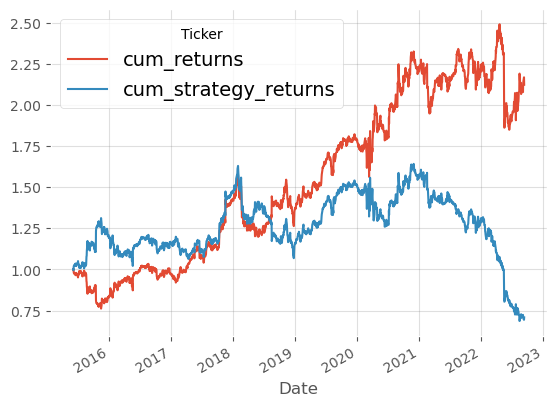

In [115]:
wmt[[x for x in wmt.columns if 'cum_' in x]].plot()

### <font color = red> Question 7</font>. Please calculate the Sharpe Ratio of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a Sharpe ratio of _________ . 

    Simple moving strategy for WMT leads to a Sharpe ratio of _________ . 

In [88]:
def compute_sharpe_ratio(daily_returns):
    """
    get_sharpe Calculate the annualized Sharpe ratio from a series of daily returns.
    Annualized Sharpe ratio computed as:
                sqrt(252) * mean(daily_returns) / std(daily_returns)
    - Assumes 252 trading days per year for annualization. Adjust the
      multiplier for a different convention.
    - Input should be returns (not prices). Convert prices to returns before
      calling this function.
    Parameters:
        daily_returns : array-like (pd.Series or np.ndarray)
    Returns:
        float
    Usage:
        compute_sharpe_ratio(df['strategy_returns'])
    """
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std(ddof =1)

f"Simple moving strategy for IBM leads to a Sharpe ratio of {compute_sharpe_ratio(ibm['strategy_returns']):.5f}" \
f"  Simple moving strategy for WMT leads to a Sharpe ratio of {compute_sharpe_ratio(wmt['strategy_returns']):.5f}" 

'Simple moving strategy for IBM leads to a Sharpe ratio of -0.16845  Simple moving strategy for WMT leads to a Sharpe ratio of -0.21239'

### <font color = red> Question 8</font>. Please calculate the Compound Annual Growth Rate (CAGR) of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a CAGR of _________ .

    Simple moving strategy for WMT leads to a CAGR of _________ .


In [95]:
def compute_cagr(cumulative_returns):
    """
    get_cagr Compute Compound Annual Growth Rate (CAGR) from a series of cumulative returns.
        - The function drops missing values and uses the first and last available
      observations to compute CAGR as:
          (last_value / first_value) ** (365.0 / n_days) - 1
      where n_days is the integer number of days between the first and last index.
        - Uses 365-day convention for annualization. For trading-day conventions
        adjust the exponent accordingly.
        - If the series contains a single observation or zero-day span, the result
        may be ill-defined (division by zero or power of inf). Consider checking
        the index span before calling.
    Parameters:
        cumulative_returns : pandas.Series. Time-indexed series of cumulative returns (e.g. cumulative growth factors)
    Returns:
        float
    """

    cumulative_returns = cumulative_returns.dropna()
    n_of_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]
                ).days
    cagr =\
    (
        (        
        cumulative_returns.iloc[-1] 
        /
        cumulative_returns.iloc[0]
        ) ** (365.25 / n_of_days)
        - 1
    )
    return cagr

In [110]:
f"    Simple moving strategy for IBM leads to a CAGR of {compute_cagr(ibm['cum_strategy_returns']):.2%} ." \
f"    Simple moving strategy for WMT leads to a CAGR of {compute_cagr(wmt['cum_strategy_returns']):.2%} ."

'    Simple moving strategy for IBM leads to a CAGR of -4.08% .    Simple moving strategy for WMT leads to a CAGR of -4.62% .'

### <font color="green">"Thank you for putting your efforts into the exercise problem sets 💯"</font>